In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# **Data Loading**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train = pd.read_csv('/content/sample_data/dataset_A_training.csv')
test = pd.read_csv('/content/sample_data/dataset_A_testing.csv')

In [ ]:
train.columns

Index(['respondent_id', 'flu_concern', 'flu_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk',
       'opinion_seas_sick_from_vacc', 'age_group', 'education', 'race', 'sex',
       'income_poverty', 'marital_status', 'rent_or_own', 'employment_status',
       'census_msa', 'household_adults', 'household_children',
       'employment_sector', 'seasonal_vaccine'],
      dtype='object')

In [ ]:
test.columns

Index(['respondent_id', 'flu_concern', 'flu_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk',
       'opinion_seas_sick_from_vacc', 'age_group', 'education', 'race', 'sex',
       'income_poverty', 'marital_status', 'rent_or_own', 'employment_status',
       'census_msa', 'household_adults', 'household_children',
       'employment_sector'],
      dtype='object')

# **Exploratory Data Analysis**

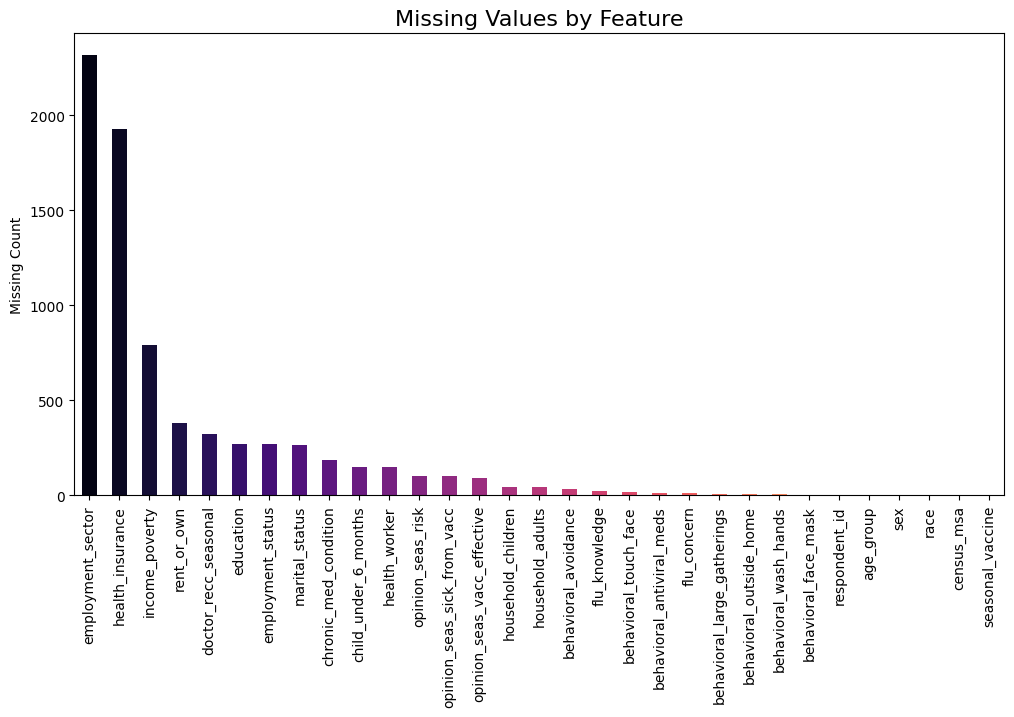

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

missing = train.isnull().sum().sort_values(ascending=False)

plt.style.use('default')

plt.figure(figsize=(12,6))
colors = sns.color_palette("magma", len(missing))

missing.plot(
    kind='bar',
    color=colors
)

plt.title('Missing Values by Feature', fontsize=16)
plt.ylabel('Missing Count')
plt.xticks(rotation=90)
plt.show()

/tmp/ipykernel_544/451423780.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


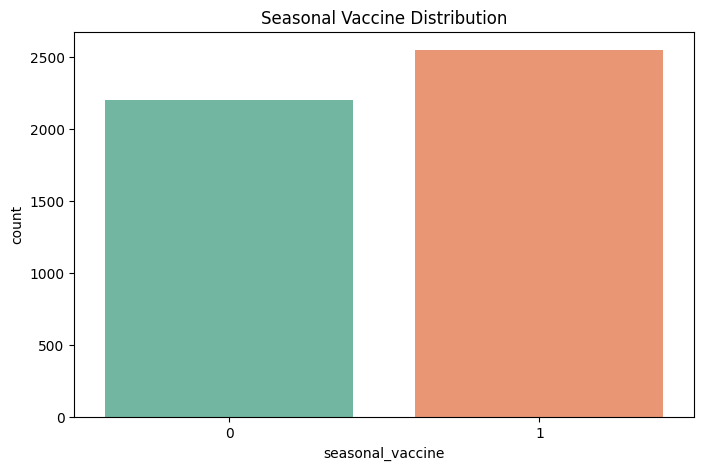

In [ ]:
plt.style.use('default')

plt.figure(figsize=(8,5))

sns.countplot(
    x='seasonal_vaccine',
    data=train,
    palette='Set2'
)

plt.title('Seasonal Vaccine Distribution')
plt.show()

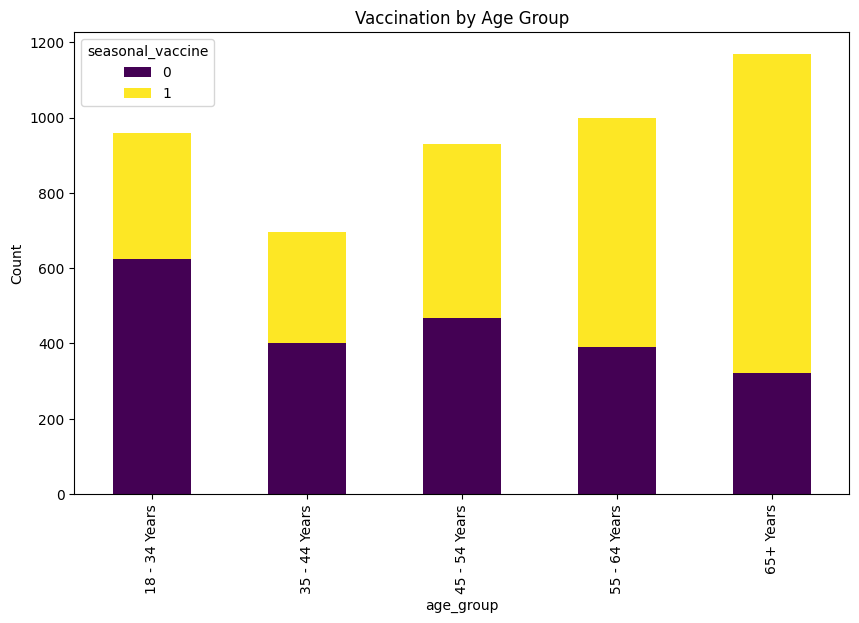

In [ ]:
age_vaccine = pd.crosstab(
    train['age_group'],
    train['seasonal_vaccine']
)

age_vaccine.plot(
    kind='bar',
    stacked=True,
    colormap='viridis',
    figsize=(10,6)
)

plt.title('Vaccination by Age Group')
plt.ylabel('Count')
plt.show()

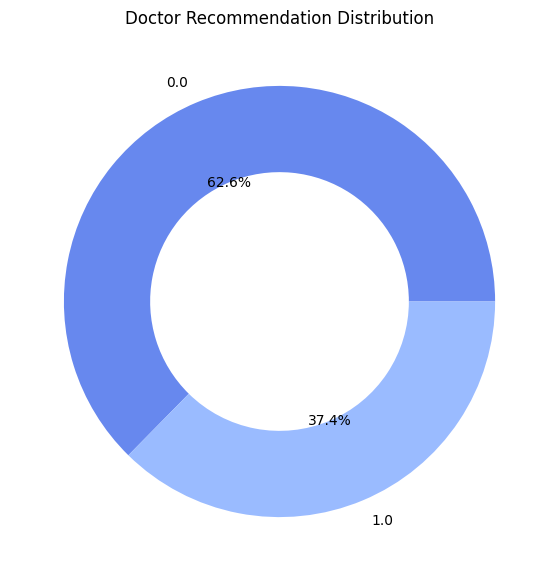

In [ ]:
doctor_counts = train['doctor_recc_seasonal'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    doctor_counts,
    labels=doctor_counts.index,
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.4),
    colors=sns.color_palette("coolwarm")
)

plt.title('Doctor Recommendation Distribution')
plt.show()

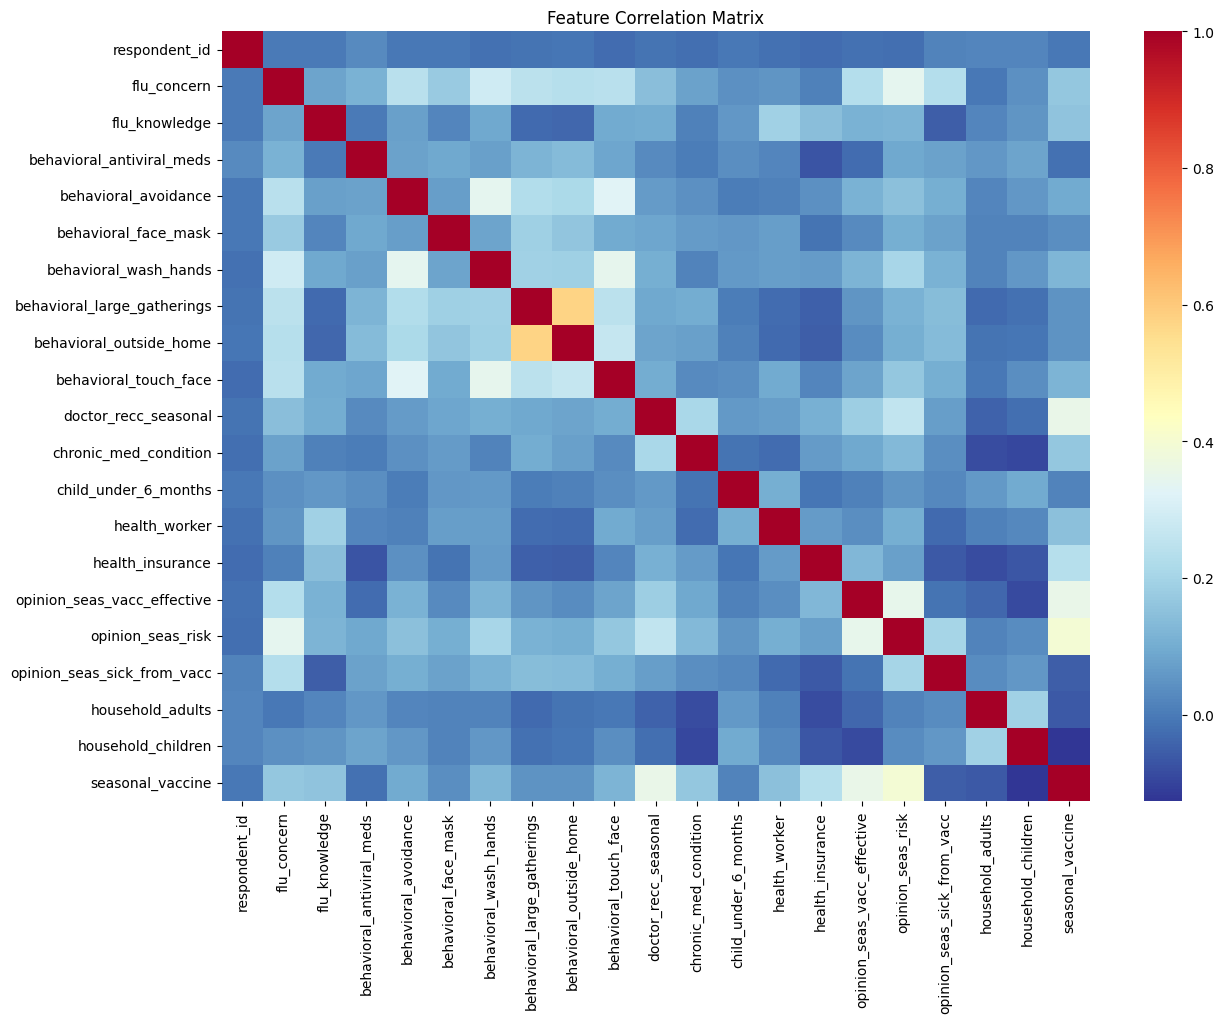

In [ ]:
plt.figure(figsize=(14,10))

corr = train.select_dtypes(
    include=['float64','int64']
).corr()

sns.heatmap(
    corr,
    cmap='RdYlBu_r',
    annot=False
)

plt.title('Feature Correlation Matrix')
plt.show()

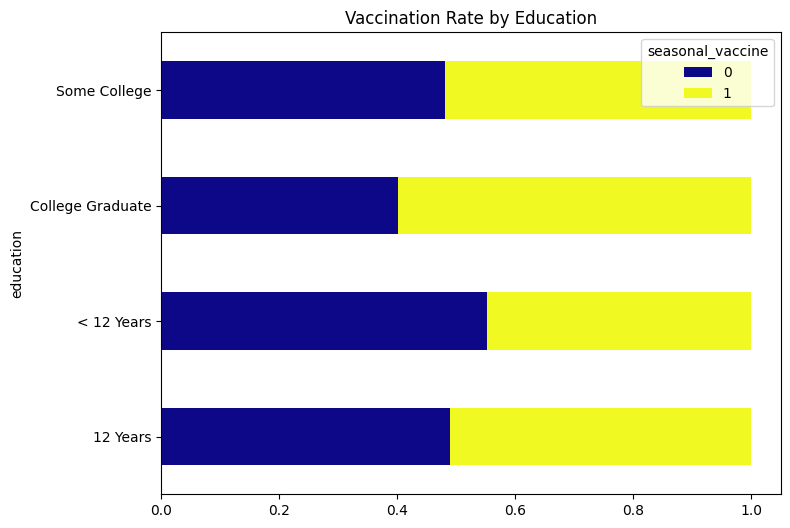

In [ ]:
edu = pd.crosstab(
    train['education'],
    train['seasonal_vaccine'],
    normalize='index'
)

edu.plot(
    kind='barh',
    stacked=True,
    colormap='plasma',
    figsize=(8,6)
)

plt.title('Vaccination Rate by Education')
plt.show()

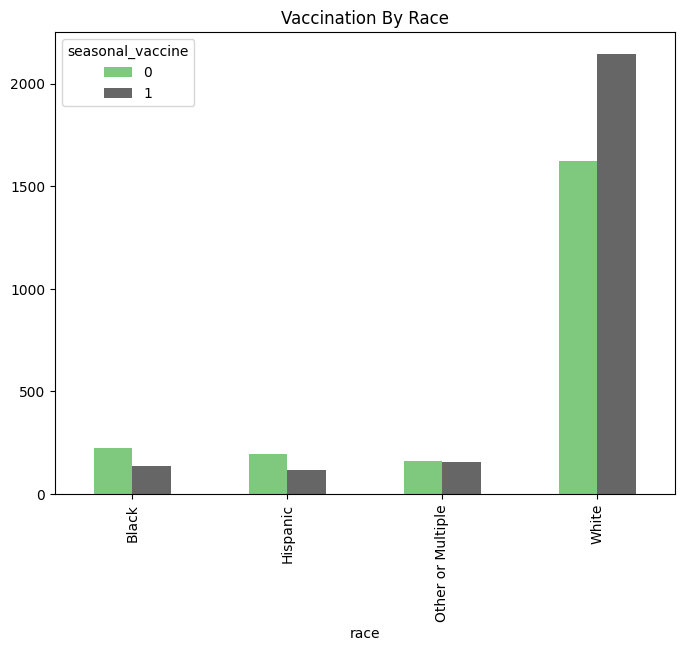

In [ ]:
race_counts = pd.crosstab(
    train['race'],
    train['seasonal_vaccine']
)

race_counts.plot(
    kind='bar',
    figsize=(8,6),
    colormap='Accent'
)

plt.title('Vaccination By Race')
plt.show()

# **Data Cleaning**

In [ ]:
set(train.columns) - set(test.columns)

{'seasonal_vaccine'}

In [ ]:
train.shape

(4756, 31)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   flu_concern                  4744 non-null   float64
 2   flu_knowledge                4733 non-null   float64
 3   behavioral_antiviral_meds    4742 non-null   float64
 4   behavioral_avoidance         4724 non-null   float64
 5   behavioral_face_mask         4753 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4747 non-null   float64
 9   behavioral_touch_face        4737 non-null   float64
 10  doctor_recc_seasonal         4435 non-null   float64
 11  chronic_med_condition        4568 non-null   float64
 12  child_under_6_months         4604 non-null   float64
 13  health_worker     

In [ ]:
train.isnull().sum()

,0
respondent_id,0
flu_concern,12
flu_knowledge,23
behavioral_antiviral_meds,14
behavioral_avoidance,32
behavioral_face_mask,3
behavioral_wash_hands,8
behavioral_large_gatherings,9
behavioral_outside_home,9
behavioral_touch_face,19


In [ ]:
train['seasonal_vaccine'].value_counts()

,count
seasonal_vaccine,
1,2551
0,2205


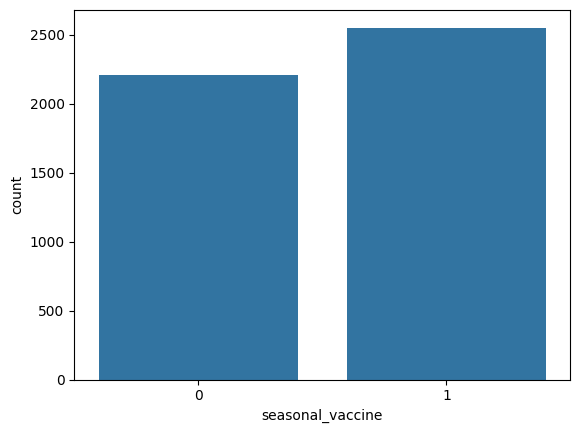

In [ ]:
sns.countplot(x='seasonal_vaccine', data=train)
plt.show()

In [ ]:
train = train.drop('respondent_id', axis=1)
test = test.drop('respondent_id', axis=1)

In [ ]:
X = train.drop('seasonal_vaccine', axis=1)
y = train['seasonal_vaccine']

In [ ]:
num_cols = X.select_dtypes(include=['int64','float64']).columns

cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk',
       'opinion_seas_sick_from_vacc', 'household_adults',
       'household_children'],
      dtype='object')

Categorical Columns:
Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'census_msa',
       'employment_sector'],
      dtype='object')


In [ ]:
for col in num_cols:
    X[col].fillna(X[col].median(), inplace=True)

/tmp/ipykernel_544/904245793.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)


In [ ]:
for col in cat_cols:
    X[col].fillna(X[col].mode()[0], inplace=True)

/tmp/ipykernel_544/1446141502.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mode()[0], inplace=True)


In [ ]:
X.isnull().sum().sum()

np.int64(0)

# **Splitting Data into Training and Validation Sets**

In [ ]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_valid.shape)

(3804, 29)
(952, 29)


# **Models Implementation**

Accuracy: 0.7773109243697479
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       441
           1       0.79      0.79      0.79       511

    accuracy                           0.78       952
   macro avg       0.78      0.78      0.78       952
weighted avg       0.78      0.78      0.78       952



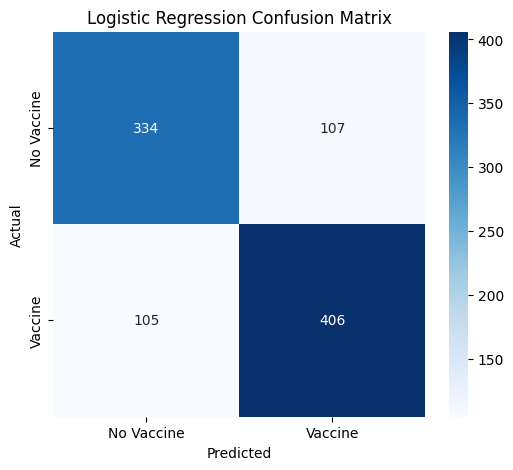

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, y_pred_lr))

print(classification_report(y_valid, y_pred_lr))

cm = confusion_matrix(y_valid, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Vaccine','Vaccine'],
    yticklabels=['No Vaccine','Vaccine']
)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **Random Forest**

Accuracy: 0.7689075630252101
              precision    recall  f1-score   support

           0       0.75      0.75      0.75       441
           1       0.78      0.78      0.78       511

    accuracy                           0.77       952
   macro avg       0.77      0.77      0.77       952
weighted avg       0.77      0.77      0.77       952



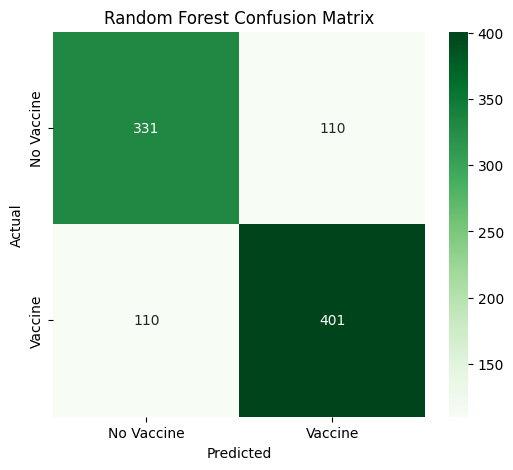

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, y_pred_rf))

print(classification_report(y_valid, y_pred_rf))

cm = confusion_matrix(y_valid, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Vaccine','Vaccine'],
    yticklabels=['No Vaccine','Vaccine']
)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Tuned Random Forest**

Accuracy: 0.7699579831932774
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       441
           1       0.78      0.79      0.79       511

    accuracy                           0.77       952
   macro avg       0.77      0.77      0.77       952
weighted avg       0.77      0.77      0.77       952



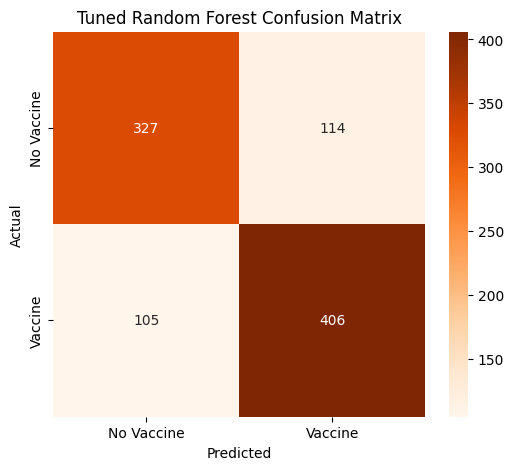

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,None],
    'min_samples_split':[2,5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, y_pred_rf_tuned))

print(classification_report(y_valid, y_pred_rf_tuned))

cm = confusion_matrix(y_valid, y_pred_rf_tuned)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['No Vaccine','Vaccine'],
    yticklabels=['No Vaccine','Vaccine']
)
plt.title('Tuned Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **4. Gradient Boosting (Purple)**

Accuracy: 0.7846638655462185
              precision    recall  f1-score   support

           0       0.77      0.76      0.77       441
           1       0.80      0.81      0.80       511

    accuracy                           0.78       952
   macro avg       0.78      0.78      0.78       952
weighted avg       0.78      0.78      0.78       952



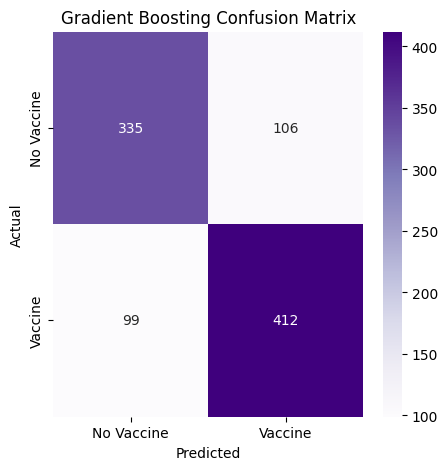

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, y_pred_gb))

print(classification_report(y_valid, y_pred_gb))

cm = confusion_matrix(y_valid, y_pred_gb)

plt.figure(figsize=(5,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Vaccine','Vaccine'],
    yticklabels=['No Vaccine','Vaccine']
)
plt.title('Gradient Boosting Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **5. XGBoost**

Accuracy: 0.7647058823529411
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       441
           1       0.79      0.77      0.78       511

    accuracy                           0.76       952
   macro avg       0.76      0.76      0.76       952
weighted avg       0.77      0.76      0.76       952



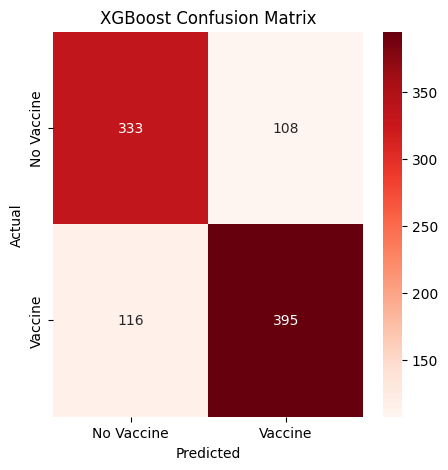

In [ ]:
!pip install xgboost -q

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, y_pred_xgb))

print(classification_report(y_valid, y_pred_xgb))

cm = confusion_matrix(y_valid, y_pred_xgb)

plt.figure(figsize=(5,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Vaccine','Vaccine'],
    yticklabels=['No Vaccine','Vaccine']
)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **Model Comparison Figure**

/tmp/ipykernel_544/3779668949.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


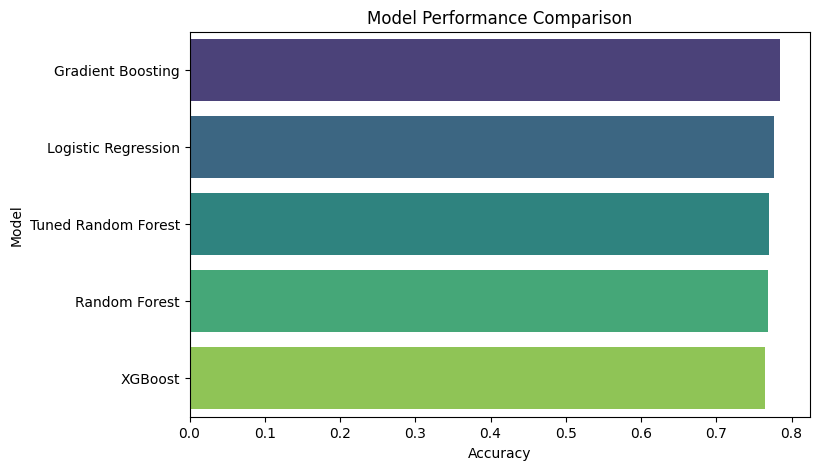

                 Model  Accuracy
3    Gradient Boosting  0.784664
0  Logistic Regression  0.777311
2  Tuned Random Forest  0.769958
1        Random Forest  0.768908
4              XGBoost  0.764706


In [ ]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'Tuned Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy':[
        accuracy_score(y_valid, y_pred_lr),
        accuracy_score(y_valid, y_pred_rf),
        accuracy_score(y_valid, y_pred_rf_tuned),
        accuracy_score(y_valid, y_pred_gb),
        accuracy_score(y_valid, y_pred_xgb)
    ]
})

results = results.sort_values(
    by='Accuracy',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Accuracy',
    y='Model',
    palette='viridis'
)

plt.title('Model Performance Comparison')
plt.show()

print(results)

In [ ]:
test_encoded = test.copy()

# Fill numerical missing values
for col in num_cols:
    test_encoded[col] = test_encoded[col].fillna(X[col].median())

# Fill categorical missing values
for col in cat_cols:
    test_encoded[col] = test_encoded[col].fillna(X[col].mode()[0])

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    test_encoded[col] = le.fit_transform(test_encoded[col])

print(test_encoded.isnull().sum().sum())

0


In [ ]:
test_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4749 entries, 0 to 4748
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   flu_concern                  4749 non-null   float64
 1   flu_knowledge                4749 non-null   float64
 2   behavioral_antiviral_meds    4749 non-null   float64
 3   behavioral_avoidance         4749 non-null   float64
 4   behavioral_face_mask         4749 non-null   float64
 5   behavioral_wash_hands        4749 non-null   float64
 6   behavioral_large_gatherings  4749 non-null   float64
 7   behavioral_outside_home      4749 non-null   float64
 8   behavioral_touch_face        4749 non-null   float64
 9   doctor_recc_seasonal         4749 non-null   float64
 10  chronic_med_condition        4749 non-null   float64
 11  child_under_6_months         4749 non-null   float64
 12  health_worker                4749 non-null   float64
 13  health_insurance  

# **Now we perform on test Data**

# **1. Gradient Boost**

In [ ]:
gb.fit(X_encoded, y)

GradientBoostingClassifier(random_state=42)

In [ ]:
pred_gb = gb.predict(test_encoded)

In [ ]:
test_ids = pd.read_csv('/content/sample_data/dataset_A_testing.csv')['respondent_id']

submission_gb = pd.DataFrame({
    'respondent_id': test_ids,
    'seasonal_vaccine': pred_gb
})

submission_gb.to_csv(
    'challenge_submission_group_E_order_1.csv',
    index=False
)

print("Submission File Created")

Submission File Created


In [ ]:
from google.colab import files

files.download('challenge_submission_group_E_order_1.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
submission_gb.head()

,respondent_id,seasonal_vaccine
0,4757,1
1,4758,1
2,4759,1
3,4760,1
4,4761,0


# **2. Logistic regression**

In [ ]:
model_lr.fit(X_encoded, y)

LogisticRegression(max_iter=1000)

In [ ]:
pred_lr = model_lr.predict(test_encoded)

In [ ]:
test_ids = pd.read_csv('/content/sample_data/dataset_A_testing.csv')['respondent_id']

submission_lr = pd.DataFrame({
    'respondent_id': test_ids,
    'seasonal_vaccine': pred_lr
})

submission_lr.to_csv(
    'challenge_submission_group_E_order_2.csv',
    index=False
)

In [ ]:
files.download('challenge_submission_group_E_order_2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **3. Tuned Random Forest**

In [ ]:
best_rf.fit(X_encoded, y)

pred_rf_tuned = best_rf.predict(test_encoded)

test_ids = pd.read_csv('/content/sample_data/dataset_A_testing.csv')['respondent_id']

submission_rf_tuned = pd.DataFrame({
    'respondent_id': test_ids,
    'seasonal_vaccine': pred_rf_tuned
})

submission_rf_tuned.to_csv(
    'challenge_submission_group_E_order_3.csv',
    index=False
)

files.download('challenge_submission_group_E_order_3.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **4. Random Forest**

In [ ]:
rf.fit(X_encoded, y)

pred_rf = rf.predict(test_encoded)

test_ids = pd.read_csv('/content/sample_data/dataset_A_testing.csv')['respondent_id']

submission_rf = pd.DataFrame({
    'respondent_id': test_ids,
    'seasonal_vaccine': pred_rf
})

submission_rf.to_csv(
    'challenge_submission_group_E_order_4.csv',
    index=False
)

files.download('challenge_submission_group_E_order_4.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **5. XGBoost**

In [ ]:
xgb.fit(X_encoded, y)

pred_xgb = xgb.predict(test_encoded)

test_ids = pd.read_csv('/content/sample_data/dataset_A_testing.csv')['respondent_id']

submission_xgb = pd.DataFrame({
    'respondent_id': test_ids,
    'seasonal_vaccine': pred_xgb
})

submission_xgb.to_csv(
    'challenge_submission_group_E_order_5.csv',
    index=False
)

files.download('challenge_submission_group_E_order_5.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Feature Importance for The best model Gradient Boosting**

/tmp/ipykernel_544/3031023811.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


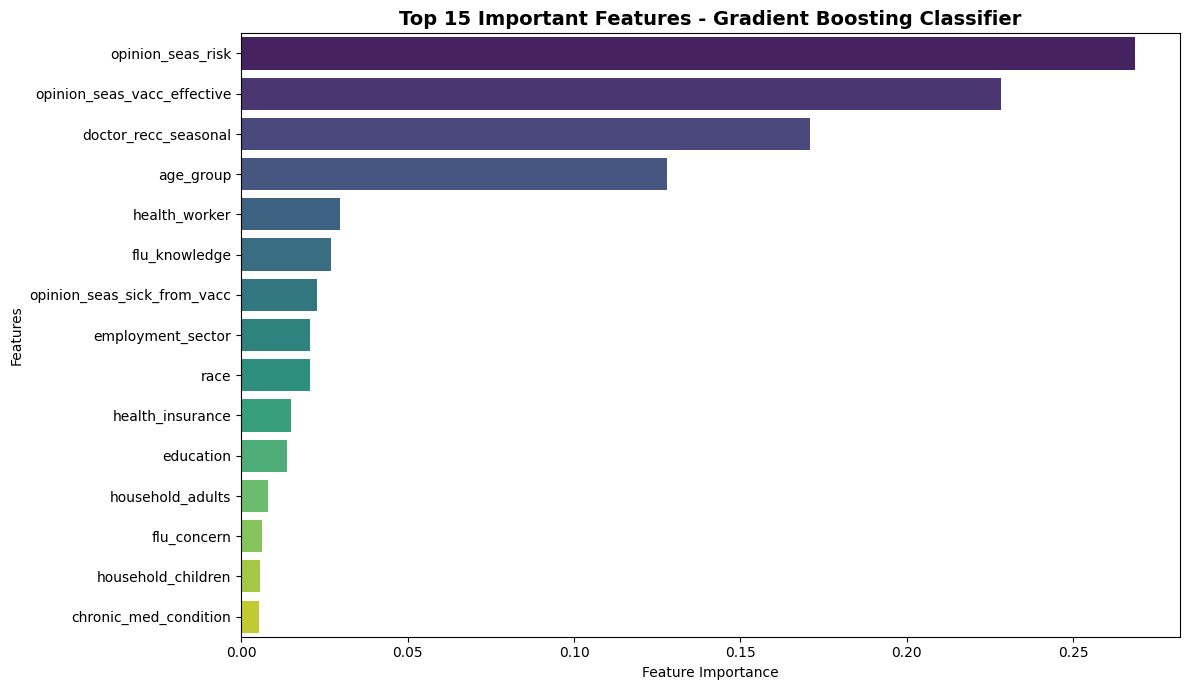

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title(
    'Top 15 Important Features - Gradient Boosting Classifier',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Feature Importance')
plt.ylabel('Features')

plt.tight_layout()

plt.show()